In [2]:
# coding: utf-8
# наше всё
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# настройки pandas, с которыми лучше почти всегда
pd.set_option('display.max_rows', 45000)
pd.set_option('display.max_columns', 50000)
pd.set_option('display.max_colwidth', 5000)

# графики в svg выглядят более четкими
%config InlineBackend.figure_format = 'svg' 
rcParams['figure.figsize'] = 16, 12

In [3]:
source_df = pd.read_excel('qval6.xlsx', sheet_name='Worksheet')

In [4]:
res_df = source_df.copy()
diff_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    diff_df[i] = np.sum(diff_df[i]) / len(diff_df[i])



pot_df = res_df.copy()
for i in range(1, len(diff_df.columns)-2):
    pot_df[i] = diff_df[i] * res_df[i]


diff_df = diff_df[0:1][diff_df.columns[3:]].T
diff_df = diff_df.reset_index()
diff_df.columns = ['question', 'difficulty']


In [5]:
diff_df.sample(3)

,question,difficulty
30,31,0.80
8,9,0.68
22,23,0.40


In [6]:
diff_df.sort_values(by='difficulty', ascending=False)[0:3]

,question,difficulty
30,31,0.80
21,22,0.72
35,36,0.72


In [7]:
diff_df.sort_values(by='difficulty', ascending=True)[0:3]

,question,difficulty
7,8,0.00
34,35,0.00
26,27,0.04


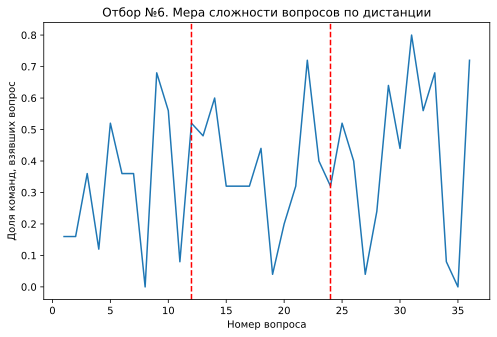

In [8]:
plt.figure(figsize=(8, 5))
sns.lineplot(data=diff_df, x='question', y='difficulty')
plt.xlabel('Номер вопроса')
plt.ylabel('Доля команд, взявших вопрос')
plt.title('Отбор №6. Мера сложности вопросов по дистанции')
#  вертикальная линия при x = 12 и x = 24
plt.axvline(x=12, color='red', linestyle='--')
plt.axvline(x=24, color='red', linestyle='--')
plt.show()


<Figure size 800x500 with 0 Axes>

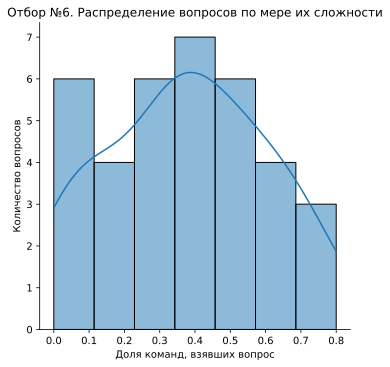

In [9]:
plt.figure(figsize=(8, 5))
sns.displot(diff_df['difficulty'], kde=True)
plt.xlabel('Доля команд, взявших вопрос')
plt.ylabel('Количество вопросов')
plt.title('Отбор №6. Распределение вопросов по мере их сложности')
plt.show()






In [10]:
team_stat = res_df[res_df.columns[0:3]].copy()
team_stat['result'] = np.sum(res_df[res_df.columns[3:]], axis=1)
team_stat['difficulty'] = np.sum(pot_df[pot_df.columns[3:]], axis=1)
team_stat['potential'] = team_stat['difficulty'] / team_stat['result']


In [11]:
team_stat.sort_values(by='result', ascending=False)

,Team ID,Название,Город,result,difficulty,potential
15,87211,Дельта Пси Хи,Москва,28,12.04,0.430000
23,107933,Игра в ящик,Москва,25,11.44,0.457600
2,79938,Идеальная линия,Москва,25,11.32,0.452800
0,64035,Совушки,Москва,22,10.40,0.472727
18,106581,Пошли в Братья Крафт,Москва,21,10.44,0.497143
21,98851,Метапопс,Москва,18,8.88,0.493333
17,107756,Приказ скифского царя,Москва,18,8.48,0.471111
13,107736,Смех не грех,Москва,17,8.64,0.508235
8,54207,Наш ответ съела ласточка,Москва,17,9.20,0.541176
19,107930,Снова о полку Игореве,Москва,15,8.08,0.538667


In [12]:
team_stat[['result']].describe()

,result
count,25.000000
mean,13.480000
std,7.411253
min,0.000000
25%,9.000000
50%,14.000000
75%,18.000000
max,28.000000


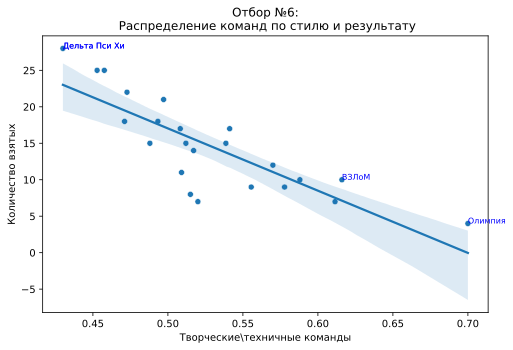

In [28]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=team_stat, 
    x="potential", 
    y="result",
    )

plt.title("Отбор №6:\n Распределение команд по стилю и результату")
# add a trend line
sns.regplot(data=team_stat, x="potential", y="result", scatter=False)

# add points
x1 = np.min(team_stat['potential'])
y1 = team_stat[team_stat['potential'] == x1]['result'].values[0]
name1 = team_stat[team_stat['potential'] == x1]['Название'].values[0]
plt.text(x1, y1, name1, fontsize=8, color='blue')

x2 = np.max(team_stat['potential'])
y2 = team_stat[team_stat['potential'] == x2]['result'].values[0]
name2 = team_stat[team_stat['potential'] == x2]['Название'].values[0]
plt.text(x2, y2, name2, fontsize=8, color='blue')

y3 = np.max(team_stat['result'])
x3 = team_stat[team_stat['result'] == y3]['potential'].values[0]
name3 = team_stat[team_stat['result'] == y3]['Название'].values[0]
plt.text(x3, y3, name3, fontsize=8, color='blue')

# y4 = np.min(team_stat['result'])
# x4 = team_stat[team_stat['result'] == y4]['potential'].values[0]
# name4 = team_stat[team_stat['result'] == y4]['Название'].values[0]
# plt.text(x4, y4, name4, fontsize=8, color='blue')

x5 = team_stat['potential'].values[np.random.randint(0, len(team_stat))]
y5 = team_stat[team_stat['potential'] == x5]['result'].values[0]
name5 = team_stat[team_stat['potential'] == x5]['Название'].values[0]
plt.text(x5, y5, name5, fontsize=8, color='blue')

plt.xlabel("Творческие\техничные команды")
plt.ylabel("Количество взятых")

plt.show()


In [14]:
# сильные техничные команды
team_stat[
    (team_stat['potential'] > np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

8     Наш ответ съела ласточка
19       Снова о полку Игореве
Name: Название, dtype: object

In [15]:
# сильные творческие команды
team_stat[
    (team_stat['potential'] < np.mean(team_stat['potential'])) & 
    (team_stat['result'] > np.mean(team_stat['result']))
]['Название']

0                   Совушки
2           Идеальная линия
10                    ФНМем
13             Смех не грех
15            Дельта Пси Хи
16         Остров Эйнштейна
17    Приказ скифского царя
18     Пошли в Братья Крафт
21                 Метапопс
23              Игра в ящик
24            Могучая кучка
Name: Название, dtype: object

In [16]:
team_stat.sort_values(by='potential', ascending=True)[0:5]

,Team ID,Название,Город,result,difficulty,potential
15,87211,Дельта Пси Хи,Москва,28,12.04,0.430000
2,79938,Идеальная линия,Москва,25,11.32,0.452800
23,107933,Игра в ящик,Москва,25,11.44,0.457600
17,107756,Приказ скифского царя,Москва,18,8.48,0.471111
0,64035,Совушки,Москва,22,10.40,0.472727


In [17]:
team_stat.sort_values(by='potential', ascending=False)[0:5]

,Team ID,Название,Город,result,difficulty,potential
20,107931,Олимпия,Москва,4,2.80,0.700000
7,107926,ВЗЛоМ,Москва,10,6.16,0.616000
3,95317,Журафы,Москва,7,4.28,0.611429
1,107922,Командир думает,Москва,10,5.88,0.588000
4,107923,ФФХИХИ,Москва,9,5.20,0.577778


In [18]:
team_qv_df = res_df.melt(
    id_vars=['Название', 'Город', 'Team ID'],
    value_vars=res_df.columns[3:],
    var_name='question',
    value_name='qv_result'
)
team_qv_df = team_qv_df.merge(
    diff_df, 
    'left',
    on='question'
)
team_qv_df = team_qv_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
team_qv_df['epic'] = team_qv_df['result'] * team_qv_df['difficulty_qv']




In [19]:
# топ эпических взятий
team_qv_df[team_qv_df['qv_result'] == 1].sort_values(by='epic', ascending=True)[0:3]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
262,Смузи!,Москва,107928,11,1,0.08,11,5.60,0.509091,0.88
452,Идеальная линия,Москва,79938,19,1,0.04,25,11.32,0.452800,1.00
665,Дельта Пси Хи,Москва,87211,27,1,0.04,28,12.04,0.430000,1.12


In [20]:
# топ эпических продолбов
team_qv_df[team_qv_df['qv_result'] == 0].sort_values(by='epic', ascending=False)[0:4]

,Название,Город,Team ID,question,qv_result,difficulty_qv,result,difficulty_total,potential,epic
340,Дельта Пси Хи,Москва,87211,14,0,0.60,28,12.04,0.4300,16.80
115,Дельта Пси Хи,Москва,87211,5,0,0.52,28,12.04,0.4300,14.56
798,Игра в ящик,Москва,107933,32,0,0.56,25,11.44,0.4576,14.00
777,Идеальная линия,Москва,79938,32,0,0.56,25,11.32,0.4528,14.00


In [21]:
res_df = res_df.merge(
    team_stat,
    'left',
    on=['Название', 'Team ID', 'Город'],
    suffixes=('_qv', '_total')
)
res_df.sample(3)


,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
8,54207,Наш ответ съела ласточка,Москва,0,0,0,0,1,0,1,0,1,0,0,1,1,1,0,0,0,0,0,0,1,1,0,0,1,1,0,1,1,1,1,1,1,0,0,1,17,9.20,0.541176
19,107930,Снова о полку Игореве,Москва,0,0,0,0,0,0,1,0,1,1,0,1,1,1,0,0,0,1,0,0,1,1,0,0,1,1,0,0,0,1,1,1,1,0,0,0,15,8.08,0.538667
23,107933,Игра в ящик,Москва,0,0,1,1,1,1,1,0,1,1,0,1,1,1,1,0,1,1,0,1,1,1,1,1,1,1,0,0,1,0,1,0,1,1,0,1,25,11.44,0.457600


In [22]:
# корреляция между столбцам в data frame
correlations_with_result = pd.DataFrame(res_df[res_df.columns[3:-2]].corr()['result'])
correlations_with_result.columns = ['correlation']
correlations_with_result.sort_values(by='correlation', ascending=False)[0:40]

,correlation
result,1.000000
6,0.684889
3,0.684889
33,0.683017
29,0.680758
13,0.653169
10,0.613452
21,0.592326
1,0.587202
2,0.587202


In [23]:
correlations_with_result.sort_values(by='correlation', ascending=True)[0:5]

,correlation
11,0.041421
32,0.136273
14,0.290099
5,0.295051
19,0.323832


In [24]:
res_df.sample(3)

,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential
11,107733,Бегущие к Житенёву,Москва,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,8,4.12,0.515
6,107925,Снова правы,Москва,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,NaN
22,107932,Острый репортаж,Москва,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,NaN


In [25]:
top_3 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:4].index)
top_5 = list(correlations_with_result.sort_values(by='correlation', ascending=False)[1:6].index)

In [26]:
res_df['top-3'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_3)]], axis=1)
res_df['top-5'] = np.sum(res_df[res_df.columns[res_df.columns.isin(top_5)]], axis=1)
res_df.sample(3)






,Team ID,Название,Город,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,result,difficulty,potential,top-3,top-5
11,107733,Бегущие к Житенёву,Москва,0,0,0,0,0,0,0,0,1,0,0,0,0,1,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,8,4.12,0.515,0,0
6,107925,Снова правы,Москва,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.00,NaN,0,0
20,107931,Олимпия,Москва,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,4,2.80,0.700,0,0


In [27]:
res_df[['top-3', 'top-5', 'result']].corr()

,top-3,top-5,result
top-3,1.000000,0.940631,0.813421
top-5,0.940631,1.000000,0.887530
result,0.813421,0.887530,1.000000
